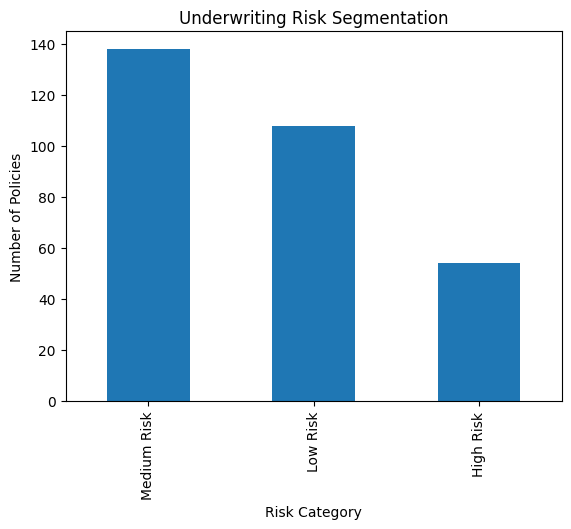

Text(0, 0.5, 'Average Loss Ratio')

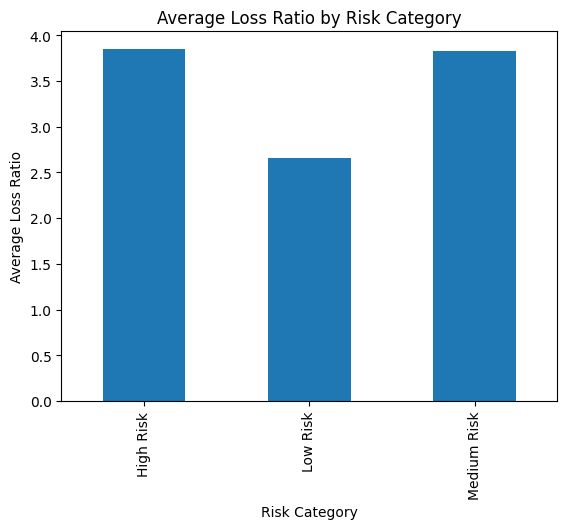

In [2]:

# A rule-based underwriting risk segmentation model designed to improve portfolio visibility and support structured risk selection.
#The model applies weighted scoring logic to key underwriting attributes including industry risk score, historical claims frequency, and prior claim severity.

import pandas as pd
import numpy as np

np.random.seed(42)

num_policies = 300

data = {
    "Policy_ID": range(1, num_policies + 1),
    "Industry_Risk_Score": np.random.randint(1, 10, num_policies),
    "Annual_Turnover": np.random.randint(50000, 2000000, num_policies),
    "Previous_Claims": np.random.randint(0, 5, num_policies),
    "Claim_Amount_Last_Year": np.random.randint(0, 50000, num_policies),
    "Premium_Charged": np.random.randint(1000, 20000, num_policies)
}

df2 = pd.DataFrame(data)

def underwriting_risk(row):
    score = 0

    score += row["Industry_Risk_Score"] * 2
    score += row["Previous_Claims"] * 3

    if row["Claim_Amount_Last_Year"] > 20000:
        score += 5

    if score <= 15:
        return "Low Risk"
    elif score <= 25:
        return "Medium Risk"
    else:
        return "High Risk"

df2["Risk_Category"] = df2.apply(underwriting_risk, axis=1)

df2["Loss_Ratio"] = df2["Claim_Amount_Last_Year"] / df2["Premium_Charged"]

import matplotlib.pyplot as plt

df2["Risk_Category"].value_counts().plot(kind="bar")
plt.title("Underwriting Risk Segmentation")
plt.xlabel("Risk Category")
plt.ylabel("Number of Policies")
plt.show()

avg_loss_ratio = df2.groupby("Risk_Category")["Loss_Ratio"].mean()
avg_loss_ratio.plot(kind="bar")
plt.title("Average Loss Ratio by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Loss Ratio")

